In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs

In [56]:
X,y = make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=2.50, random_state=40)

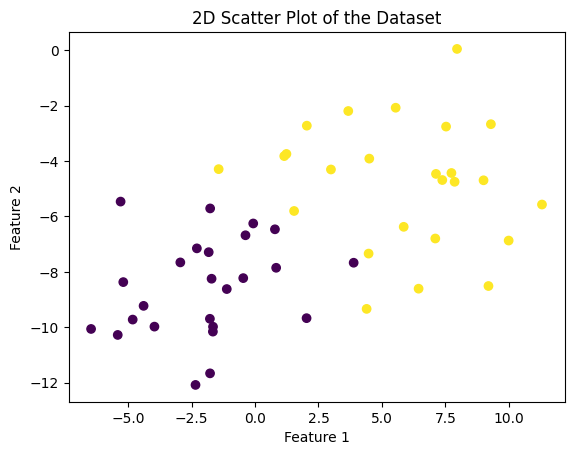

In [57]:
X1 = X[:, :-1]
X2 = X[:,-1]

plt.scatter(X1, X2, c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Scatter Plot of the Dataset')
plt.show()

In [58]:
svm = SVC(kernel='linear', C=1.0)
svm.fit(X, y)
y_pred = svm.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 96.00%


In [65]:
w = svm.coef_[0]
b = svm.intercept_[0]
print(f'Weights: {w}, Bias: {b}')

Weights: [0.52766467 0.79345209], Bias: 4.463822410501314


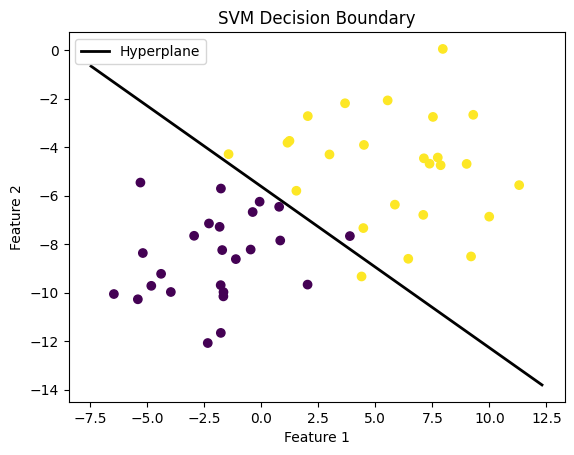

In [67]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_plot = np.linspace(x_min, x_max, 200)
y_hyperplane = -(w[0] * x_plot + b) / w[1]
plt.plot(x_plot, y_hyperplane, 'k-', linewidth=2, label='Hyperplane')
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SVM Decision Boundary')
plt.legend()
plt.show()


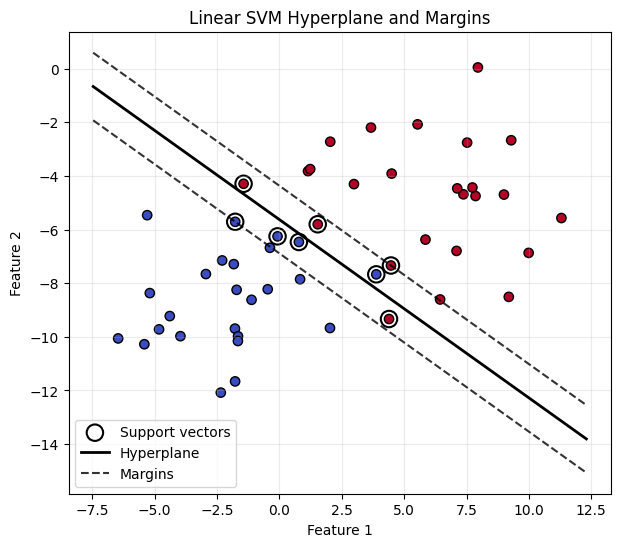

In [59]:
# plot hyperplane (decision boundary) + margins for linear SVM
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=45, edgecolors='k')

# Highlight support vectors
plt.scatter(
    svm.support_vectors_[:, 0],
    svm.support_vectors_[:, 1],
    s=140,
    facecolors='none',
    edgecolors='k',
    linewidths=1.5,
    label='Support vectors',
)

w = svm.coef_[0]
b = svm.intercept_[0]

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_plot = np.linspace(x_min, x_max, 200)

# Handle vertical boundary (rare but possible)
if abs(w[1]) < 1e-12:
    x0 = -b / w[0]
    plt.axvline(x0, color='k', linestyle='-', label='Hyperplane')
    # margins: w.x + b = ±1
    x0m1 = (-b - 1) / w[0]
    x0p1 = (-b + 1) / w[0]
    plt.axvline(x0m1, color='k', linestyle='--', alpha=0.8, label='Margins')
    plt.axvline(x0p1, color='k', linestyle='--', alpha=0.8)
else:
    # Hyperplane: w0*x + w1*y + b = 0 => y = -(w0*x + b)/w1
    y_h = -(w[0] * x_plot + b) / w[1]
    y_m1 = -(w[0] * x_plot + b - 1) / w[1]  # margin (decision_function = +1)
    y_p1 = -(w[0] * x_plot + b + 1) / w[1]  # margin (decision_function = -1)
    plt.plot(x_plot, y_h, 'k-', linewidth=2, label='Hyperplane')
    plt.plot(x_plot, y_m1, 'k--', alpha=0.8, label='Margins')
    plt.plot(x_plot, y_p1, 'k--', alpha=0.8)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linear SVM Hyperplane and Margins')
plt.legend(loc='best')
plt.grid(True, alpha=0.25)
plt.show()